# 환경

In [1]:
import os
import sys

PROJECT_ROOT = os.path.expanduser("~/jowithu/Semantic/IEC")
os.chdir(PROJECT_ROOT)

for p in [
    PROJECT_ROOT,
    os.path.join(PROJECT_ROOT, "mainldm"),      # ← 추가
    os.path.join(PROJECT_ROOT, "mainddpm"),
    os.path.join(PROJECT_ROOT, "src", "taming-transformers"),
]:
    if p not in sys.path:
        sys.path.insert(0, p)
        
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"

import torch
print("CWD:", os.getcwd())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())  # 1 나와야 정상
print("GPU:", torch.cuda.get_device_name(0))

CWD: /home/user/jowithu/Semantic/IEC
PyTorch: 2.0.1+cu118
CUDA available: True
Device count: 4
GPU: NVIDIA GeForce RTX 4090


# S-IEC 컴포넌트 sanity check

In [2]:
from siec_core.syndrome import compute_syndrome
from siec_core.correction import compute_gamma, apply_consensus_correction
from siec_core.threshold import calibrate_tau_from_scores

import torch
import numpy as np

# Toy와 구현 일치 확인
torch.manual_seed(0)
x0_a = torch.randn(4, 3, 8, 8)
x0_b = torch.randn(4, 3, 8, 8)

syn, score = compute_syndrome(x0_a, x0_b)
d = 3 * 8 * 8
expected = ((x0_a[0] - x0_b[0]) ** 2).sum().item() / d
print(f"Score[0]: {score[0].item():.6f}  (expected {expected:.6f})")
assert abs(expected - score[0].item()) < 1e-5

gamma = compute_gamma(0.8, 0.2, c=1.0)
expected_gamma = 0.2 / 1.2
print(f"Gamma: {gamma:.6f}  (expected {expected_gamma:.6f})")
assert abs(gamma - expected_gamma) < 1e-5

print("\n✓ siec_core sanity OK")

Score[0]: 2.019359  (expected 2.019359)
Gamma: 0.166667  (expected 0.166667)

✓ siec_core sanity OK


# args 구성

In [3]:
import argparse
import yaml

def dict2namespace(d):
    ns = argparse.Namespace()
    for k, v in d.items():
        setattr(ns, k, dict2namespace(v) if isinstance(v, dict) else v)
    return ns

args_dict = {
    'config': './mainddpm/configs/cifar10.yml',
    'seed': 1234 + 9,
    'device': 'cuda',
    'exp': 'deepcache',
    'image_folder': './error_dec/cifar/image_siec_pilot_nb',
    'fid': True,
    'interpolation': False, 'resume_training': False, 'ni': True,
    'use_pretrained': True,
    'sample_type': 'generalized', 'skip_type': 'quad',
    'timesteps': 100, 'eta': 0.0,
    'sequence': False, 'select_step': None, 'select_depth': None,
    'cache': True, 'replicate_interval': 10,
    'non_uniform': False, 'pow': None, 'center': None,
    'branch': 2,
    'num_samples': 500,   # pilot은 500
    'sample_batch': 100,
    'sm_abit': 8, 'quant_act': True,
    'weight_bit': 8, 'act_bit': 8, 'quant_mode': 'qdiff',
    'lr_w': 1e-4, 'lr_a': 1e-4, 'lr_z': 1e-4,
    'split': True, 'ptq': True, 'dps_steps': False, 'recon': False,
    # S-IEC
    'use_siec': True,
    'c_siec': 1.0,
    'tau_path': './calibration/tau_schedule_p80.pt',
    'tau_percentile': 80.0,
    'siec_always_correct': False,
    'siec_collect_scores': False,
    'siec_scores_out': './calibration/pilot_scores_nb.pt',
    'siec_max_rounds': 1,
}
args = dict2namespace(args_dict)

with open(args.config, 'r') as f:
    config = dict2namespace(yaml.safe_load(f))
config.select_step = args.select_step
config.select_depth = args.select_depth

args.mode = 'dps_opt' if args.dps_steps else 'uni'

os.makedirs(args.image_folder, exist_ok=True)
os.makedirs('./calibration', exist_ok=True)

print(f"args ready. num_samples={args.num_samples}, batch={args.sample_batch}")

args ready. num_samples=500, batch=100


# GPU 설정

In [4]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import logging
from accelerate import Accelerator
import torch

device = torch.device("cuda:0")
torch.cuda.set_device(device)

/home/user/anaconda3/envs/iec/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 모델 로드

In [5]:
import logging
from accelerate import Accelerator

# ★ CLI 스크립트와 동일한 import 경로 사용
from quant.utils import seed_everything
from quant.quant_model import QModel
from quant.set_quantize_params import set_act_quantize_params, set_weight_quantize_params
from ddpm.runners.deepcache import Diffusion   # ← mainddpm. prefix 제거

import torch

logging.basicConfig(level=logging.INFO)

accelerator = Accelerator()
args.accelerator = accelerator
seed_everything(args.seed)

# Calibration 로드
cal_path = f"./calibration/cifar{args.timesteps}_cache{args.replicate_interval}_{args.mode}.pth"
interval_seq, all_cali_data, all_t, all_cali_t, all_cache = torch.load(cal_path)
args.interval_seq = interval_seq
print(f"interval_seq: {list(interval_seq)}")

# Diffusion + Model
runner = Diffusion(args, config, interval_seq=args.interval_seq)
model = runner.creat_model()

abcov_path = f"./error_dec/cifar/pre_cacheerr_abCov_interval{args.replicate_interval}_list_timesteps{args.timesteps}.pth"
a_list, b_list = torch.load(abcov_path)
model.a_list = torch.stack(a_list)
model.b_list = torch.stack(b_list)
model.timesteps = args.timesteps

# Quant setup
wq_params = {'n_bits': args.weight_bit, 'symmetric': False, 'channel_wise': True, 'scale_method': 'mse'}
aq_params = {'n_bits': args.act_bit, 'symmetric': False, 'channel_wise': False,
             'scale_method': 'mse', 'leaf_param': args.quant_act,
             "prob": 1.0, "num_timesteps": args.timesteps}

q_unet = QModel(model, args, wq_params=wq_params, aq_params=aq_params)
q_unet.cuda()
q_unet.eval()
q_unet.set_first_last_layer_to_8bit()
q_unet.set_quant_state(False, False)
if args.split:
    q_unet.model.config.split_shortcut = True

cali_data_cat = torch.cat(all_cali_data)
t_cat = torch.cat(all_t)
idx = torch.randperm(len(cali_data_cat))[:32]
set_weight_quantize_params(q_unet, cali_data=(cali_data_cat[idx], t_cat[idx]))
set_act_quantize_params(args.interval_seq, q_unet, all_cali_data, all_t, all_cache)

pre_err_list = torch.load(
    f"./error_dec/cifar/pre_quanterr_abCov_weight{args.weight_bit}_interval{args.replicate_interval}_list_timesteps{args.timesteps}.pth"
)
q_unet.model.up[1].block[2].nin_shortcut.pre_err = pre_err_list
q_unet.set_quant_state(True, True)

print(f"\n✓ Model ready, GPU mem: {torch.cuda.memory_allocated()/1e9:.2f} GB")

interval_seq: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]


INFO:ddpm.runners.deepcache:Sampling in DeepCache mode
INFO:ddpm.runners.deepcache:Loading checkpoint ./atlas/u/tsong/.cache/diffusion_models_converted/ema_diffusion_cifar10_model/model-790000.ckpt
INFO:ddpm.runners.deepcache:<All keys matched successfully>
INFO:quant.set_quantize_params:set_weight_quantize_params
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_layer:split at 256!
INFO:quant.quant_l


✓ Model ready, GPU mem: 0.30 GB


# 실험


REAL EXPERIMENT: Syndrome Observability
desired timesteps: [20, 50, 100, 150, 180]
mapping:
  desired t=20 -> actual t=20
  desired t=50 -> actual t=51
  desired t=100 -> actual t=99
  desired t=150 -> actual t=150
  desired t=180 -> actual t=180
actual test timesteps: [20, 51, 99, 150, 180]

[t=20] running...
  done

[t=51] running...
  done

[t=99] running...
  done

[t=150] running...
  done

[t=180] running...


INFO:matplotlib.mathtext:Substituting symbol \perp from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol \perp from STIXGeneral


  done

Elapsed: 478.6s


INFO:matplotlib.mathtext:Substituting symbol \perp from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol \perp from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol \perp from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol \perp from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol \perp from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol \perp from STIXGeneral


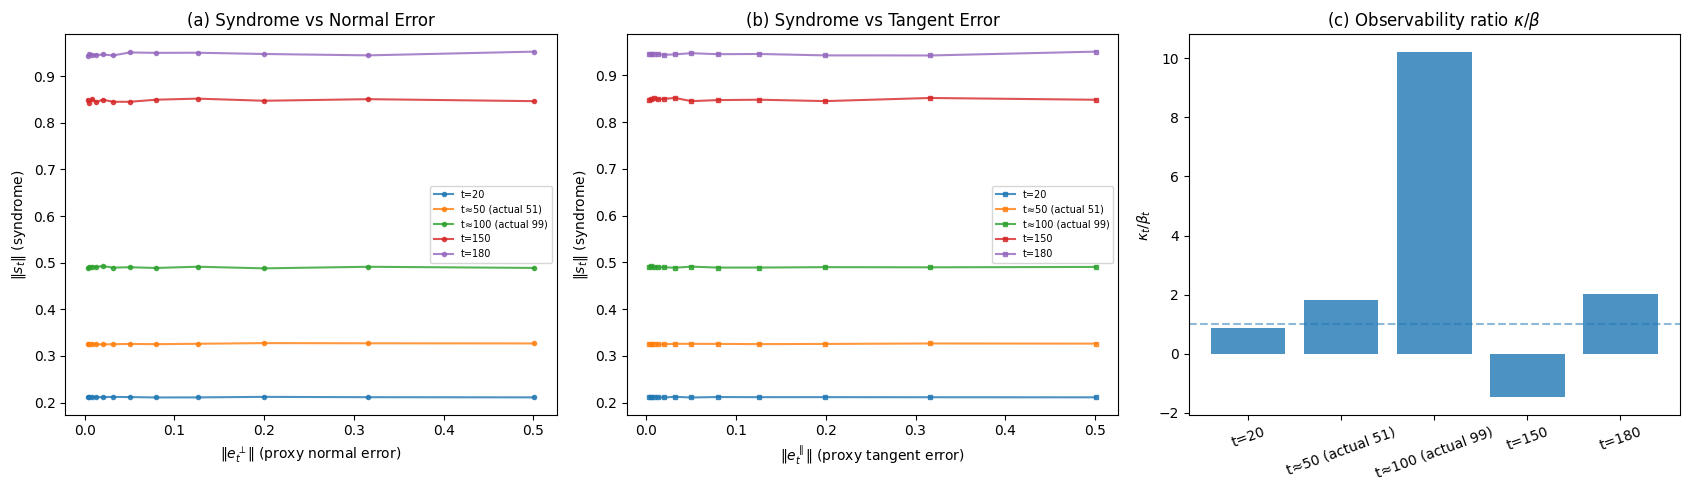


Saved figure: ./hoeun_results_real_ddpm/real_observability_fixed.png

κ/β ratios:
  t=20: 0.8702422458597073
  t≈50 (actual 51): 1.8181984921384653
  t≈100 (actual 99): 10.225852975816858
  t=150: -1.4795746337620388
  t=180: 2.0074987025218407
done


In [6]:
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

OUTDIR = "./hoeun_results_real_ddpm"
os.makedirs(OUTDIR, exist_ok=True)

device = torch.device("cuda:0")
q_unet.to(device)
q_unet.eval()


# ============================================================
# 1. alpha_bar: original DDPM timestep 기준
# ============================================================
def get_alpha_bar(args, config, device):
    beta_start = config.diffusion.beta_start
    beta_end = config.diffusion.beta_end

    num_timesteps = 1000  # original DDPM training timestep 기준

    betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

    return alpha_bars


# ============================================================
# 2. desired timestep -> available timestep mapping
# ============================================================
def map_desired_to_available(desired, available):
    mapped = []
    mapping = {}

    for t in desired:
        nearest = min(available, key=lambda x: abs(x - t))
        mapped.append(nearest)
        mapping[t] = nearest

    mapped = list(dict.fromkeys(mapped))
    return mapped, mapping


def get_prev_t(t, available):
    """
    denoising 방향: t -> 더 작은 timestep
    예: 51 -> 47, 99 -> 94, 180 -> 172
    """
    seq = [int(x) for x in available]
    t_int = int(t[0].item())

    if t_int not in seq:
        raise ValueError(f"t={t_int} not in available timesteps")

    idx = seq.index(t_int)

    if idx == 0:
        prev_t = seq[idx]
    else:
        prev_t = seq[idx - 1]

    return torch.full_like(t, prev_t)


# ============================================================
# 3. model utils
# ============================================================
@torch.no_grad()
def predict_eps(unet, x, t):
    x = x.to(device)
    t = t.to(device).long()

    out = unet(x, t)

    if isinstance(out, (tuple, list)):
        out = out[0]

    return out


@torch.no_grad()
def predict_x0(x_t, eps, t, alpha_bar):
    t = t.long()

    if t.max().item() >= len(alpha_bar):
        raise ValueError(
            f"t={t.max().item()} exceeds alpha_bar length={len(alpha_bar)}"
        )

    a = alpha_bar[t].view(-1, 1, 1, 1)
    x0 = (x_t - torch.sqrt(1.0 - a) * eps) / torch.sqrt(a)

    return x0


@torch.no_grad()
def ddim_prev(x_t, x0, eps, t, alpha_bar, available):
    t_prev = get_prev_t(t, available)

    a_prev = alpha_bar[t_prev].view(-1, 1, 1, 1)
    x_prev = torch.sqrt(a_prev) * x0 + torch.sqrt(1.0 - a_prev) * eps

    return x_prev, t_prev


# ============================================================
# 4. syndrome
# ============================================================
@torch.no_grad()
def compute_syndrome(unet, x_t, t, alpha_bar, available):
    eps = predict_eps(unet, x_t, t)
    x0_curr = predict_x0(x_t, eps, t, alpha_bar)

    x_prev, t_prev = ddim_prev(
        x_t=x_t,
        x0=x0_curr,
        eps=eps,
        t=t,
        alpha_bar=alpha_bar,
        available=available,
    )

    eps_prev = predict_eps(unet, x_prev, t_prev)
    x0_look = predict_x0(x_prev, eps_prev, t_prev, alpha_bar)

    syn = x0_curr - x0_look
    syn_norm = syn.flatten(1).norm(dim=1)

    return syn_norm


# ============================================================
# 5. PCA tangent / normal proxy
# ============================================================
@torch.no_grad()
def build_pca(x, rank=32):
    x = x.flatten(1)
    x = x - x.mean(dim=0, keepdim=True)

    _, _, Vh = torch.linalg.svd(x, full_matrices=False)

    rank = min(rank, Vh.shape[0])
    return Vh[:rank]


@torch.no_grad()
def proj_tangent(v, basis):
    shape = v.shape
    vf = v.flatten(1)

    proj = (vf @ basis.T) @ basis
    return proj.view(shape)


@torch.no_grad()
def proj_normal(v, basis):
    return v - proj_tangent(v, basis)


# ============================================================
# 6. main experiment
# ============================================================
@torch.no_grad()
def run_exp(
    q_unet,
    all_cali_data,
    all_t,
    args,
    config,
    desired_timesteps=[20, 50, 100, 150, 180],
    eta_values=None,
    n_per_timestep=32,
    pca_rank=32,
):
    print("\n" + "=" * 70)
    print("REAL EXPERIMENT: Syndrome Observability")
    print("=" * 70)

    alpha_bar = get_alpha_bar(args, config, device)

    x_all = torch.cat(all_cali_data).to(device)
    t_all = torch.cat(all_t).long().to(device)

    available = sorted(torch.unique(t_all).detach().cpu().tolist())
    available = [int(t) for t in available if int(t) < len(alpha_bar)]

    test_ts, mapping = map_desired_to_available(desired_timesteps, available)

    print("desired timesteps:", desired_timesteps)
    print("mapping:")
    for k, v in mapping.items():
        print(f"  desired t={k} -> actual t={v}")

    print("actual test timesteps:", test_ts)

    if eta_values is None:
        eta_values = np.logspace(-2.5, -0.3, 12)

    results = {}
    t0 = time.time()

    for t_test in test_ts:
        print(f"\n[t={t_test}] running...")

        mask = t_all == t_test
        x_pool = x_all[mask]

        if len(x_pool) < 4:
            print(f"  skip t={t_test}: not enough samples")
            continue

        if len(x_pool) > n_per_timestep:
            idx = torch.randperm(len(x_pool), device=device)[:n_per_timestep]
            x_pool = x_pool[idx]

        local_rank = min(pca_rank, len(x_pool) - 1)
        local_rank = max(local_rank, 1)

        basis = build_pca(x_pool, rank=local_rank)

        res = {
            "eta": [],
            "e_t": [],
            "e_n": [],
            "s_t": [],
            "s_n": [],
        }

        for eta in eta_values:
            et_list, en_list = [], []
            st_list, sn_list = [], []

            for x in x_pool:
                x = x.unsqueeze(0)
                t = torch.tensor([t_test], device=device, dtype=torch.long)

                noise = torch.randn_like(x)
                noise = noise / (
                    noise.flatten(1).norm(dim=1).view(-1, 1, 1, 1) + 1e-12
                )

                nt = proj_tangent(noise, basis)
                nt = nt / (
                    nt.flatten(1).norm(dim=1).view(-1, 1, 1, 1) + 1e-12
                )

                nn = proj_normal(noise, basis)
                nn = nn / (
                    nn.flatten(1).norm(dim=1).view(-1, 1, 1, 1) + 1e-12
                )

                xt = x + eta * nt
                xn = x + eta * nn

                et_list.append((xt - x).flatten(1).norm(dim=1).item())
                en_list.append((xn - x).flatten(1).norm(dim=1).item())

                q_unet.set_quant_state(True, True)

                st = compute_syndrome(q_unet, xt, t, alpha_bar, available)
                sn = compute_syndrome(q_unet, xn, t, alpha_bar, available)

                st_list.append(st.item())
                sn_list.append(sn.item())

            res["eta"].append(float(eta))
            res["e_t"].append(float(np.mean(et_list)))
            res["e_n"].append(float(np.mean(en_list)))
            res["s_t"].append(float(np.mean(st_list)))
            res["s_n"].append(float(np.mean(sn_list)))

        results[t_test] = res
        print("  done")

    elapsed = time.time() - t0
    print(f"\nElapsed: {elapsed:.1f}s")

    if len(results) == 0:
        raise RuntimeError("No valid results.")

    return results, mapping


# ============================================================
# 7. plotting
# ============================================================
def plot_results(results, mapping, outdir):
    actual_to_desired = {}
    for desired_t, actual_t in mapping.items():
        actual_to_desired[actual_t] = desired_t

    def label_for(actual_t):
        desired_t = actual_to_desired.get(actual_t, actual_t)

        if desired_t == actual_t:
            return f"t={actual_t}"
        else:
            return f"t≈{desired_t} (actual {actual_t})"

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # (a) Normal error
    ax = axes[0]
    for t, r in results.items():
        ax.plot(
            r["e_n"],
            r["s_n"],
            "o-",
            markersize=3,
            label=label_for(t),
            alpha=0.8,
        )

    ax.set_xlabel(r"$\|e_t^\perp\|$ (proxy normal error)")
    ax.set_ylabel(r"$\|s_t\|$ (syndrome)")
    ax.set_title("(a) Syndrome vs Normal Error")
    ax.legend(fontsize=7)

    # (b) Tangent error
    ax = axes[1]
    for t, r in results.items():
        ax.plot(
            r["e_t"],
            r["s_t"],
            "s-",
            markersize=3,
            label=label_for(t),
            alpha=0.8,
        )

    ax.set_xlabel(r"$\|e_t^\parallel\|$ (proxy tangent error)")
    ax.set_ylabel(r"$\|s_t\|$ (syndrome)")
    ax.set_title("(b) Syndrome vs Tangent Error")
    ax.legend(fontsize=7)

    # (c) ratio
    ax = axes[2]
    ratios = []
    labels = []

    for t, r in results.items():
        en = np.array(r["e_n"])
        sn = np.array(r["s_n"])
        et = np.array(r["e_t"])
        st = np.array(r["s_t"])

        kappa = np.polyfit(en, sn, 1)[0]
        beta = np.polyfit(et, st, 1)[0]

        ratio = np.nan if abs(beta) < 1e-8 else kappa / beta

        ratios.append(ratio)
        labels.append(label_for(t))

    ax.bar(range(len(ratios)), np.nan_to_num(ratios, nan=0.0), alpha=0.8)
    ax.set_xticks(range(len(ratios)))
    ax.set_xticklabels(labels, rotation=20)
    ax.axhline(y=1.0, linestyle="--", alpha=0.5)
    ax.set_ylabel(r"$\kappa_t / \beta_t$")
    ax.set_title(r"(c) Observability ratio $\kappa/\beta$")

    plt.tight_layout()

    save_path = os.path.join(outdir, "real_observability_fixed.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    print(f"\nSaved figure: {save_path}")

    print("\nκ/β ratios:")
    for label, ratio in zip(labels, ratios):
        print(f"  {label}: {ratio}")


# ============================================================
# 8. run
# ============================================================
desired_timesteps = [20, 50, 100, 150, 180]

results, mapping = run_exp(
    q_unet=q_unet,
    all_cali_data=all_cali_data,
    all_t=all_t,
    args=args,
    config=config,
    desired_timesteps=desired_timesteps,
    eta_values=np.logspace(-2.5, -0.3, 12),
    n_per_timestep=32,
    pca_rank=32,
)

plot_results(results, mapping, OUTDIR)

print("done")